In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [2]:
from tensorflow import keras
from keras import layers

In [3]:
df = pd.read_csv("geopolitical_dataset.csv")

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   military_power_ratio  1000 non-null   float64
 1   troop_movement        1000 non-null   int64  
 2   nuclear_capability    1000 non-null   int64  
 3   nuclear_warheads      1000 non-null   int64  
 4   gdp_ratio             1000 non-null   float64
 5   sanctions_intensity   1000 non-null   int64  
 6   trade_dependency      1000 non-null   float64
 7   ideology_distance     1000 non-null   float64
 8   political_stability   1000 non-null   float64
 9   historical_conflict   1000 non-null   int64  
 10  border_distance       1000 non-null   float64
 11  news_sentiment        1000 non-null   float64
 12  nationalism_index     1000 non-null   float64
 13  leader_aggression     1000 non-null   float64
 14  target                1000 non-null   int64  
dtypes: float64(9), int64(6)
memory us

In [5]:
df.sample()

,military_power_ratio,troop_movement,nuclear_capability,nuclear_warheads,gdp_ratio,sanctions_intensity,trade_dependency,ideology_distance,political_stability,historical_conflict,border_distance,news_sentiment,nationalism_index,leader_aggression,target
730,0.746399,79,1,238,1.194672,6,0.387223,0.209306,0.932444,5,587.69447,0.631642,0.678393,0.946791,2


In [6]:
x = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [7]:
y.shape

(1000,)

In [8]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size= 0.15, random_state= 11)

In [9]:
x_train, x_cv, y_train, y_cv = train_test_split(x_train,y_train,test_size= 0.18, random_state= 11)

## Data split confirmation

In [10]:
x_train.shape

(697, 14)

In [11]:
x_test.shape

(150, 14)

In [12]:
x_cv.shape

(153, 14)

### Standardization

In [13]:
scaler = StandardScaler()

x_train_std = scaler.fit_transform(x_train)
x_test_std = scaler.fit_transform(x_test)
x_cv_std = scaler.fit_transform(x_cv)

## Objective
<hr>

## The objective of this project to develop a machine learning based classification model that predicts the geopolitical state between two countries using multi - demensional fetures. The model needs aims to classify the relationship into multiple categories(Peace, Stractegic competition, cold war, proxy war, direct war) based on factors such as military strength nuclear capabilities, eco conditions , ideological diff, political stability, historical conflicts and sentiment analysis derved from media and public dicourses.


### This study seeks to :
- Identify and enguneer menaningful feature that influence global tensions
- analyze the different factors on conflict exclatation 
### Build and evaluate neural network model  using proper pre processing techniques 
- Optimize model performances to hyperparameters tuning and validation strategious

Goal is to predictive a framework that can assist in understanding and broadcasting gobal conflict dynamics using data driven approach

## Model 

In [14]:
model = keras.Sequential([
    layers.Dense(units=32, activation='relu', input_shape=(14,)),
    
    layers.Dense(units=16, activation='relu'),
    
    layers.Dense(units=8, activation='relu'),
    
    layers.Dense(units=5, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.summary()



d:\Learning\Machine_learning\venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │            45 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,189 (4.64 KB)

 Trainable params: 1,189 (4.64 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
history = model.fit(x_train_std, y_train, epochs=100, batch_size=10,validation_data=(x_cv_std,y_cv))

Epoch 1/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4118 - loss: 1.3878 - val_accuracy: 0.4314 - val_loss: 1.2846
Epoch 2/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5581 - loss: 1.1551 - val_accuracy: 0.5556 - val_loss: 1.1653
Epoch 3/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6212 - loss: 1.0215 - val_accuracy: 0.5425 - val_loss: 1.0275
Epoch 4/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6729 - loss: 0.8609 - val_accuracy: 0.6144 - val_loss: 0.8405
Epoch 5/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7274 - loss: 0.6857 - val_accuracy: 0.6601 - val_loss: 0.6893
Epoch 6/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7862 - loss: 0.5437 - val_accuracy: 0.7843 - val_loss: 0.5529
Epoch 7/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8709 - loss: 0.4440 - val_accuracy: 0.8301 - val_loss: 0.4695
Epoch 8/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8910 - loss: 0.3710 - val_accuracy: 0.8497 - v

In [16]:
import matplotlib.pyplot  as plt

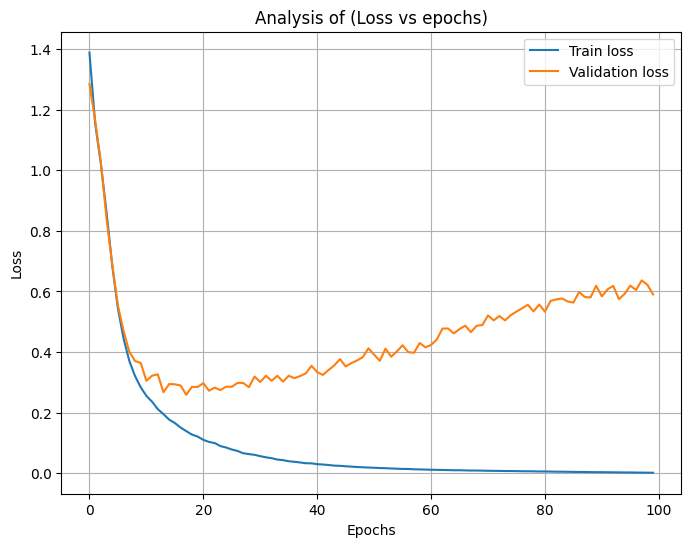

In [17]:
l = history.history['loss']
t = history.history['val_loss']
plt.figure(figsize=(8, 6))
plt.plot(l,label = "Train loss")
plt.plot(t,label = "Validation loss")

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Analysis of (Loss vs epochs)')
plt.legend()
plt.grid(True)

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


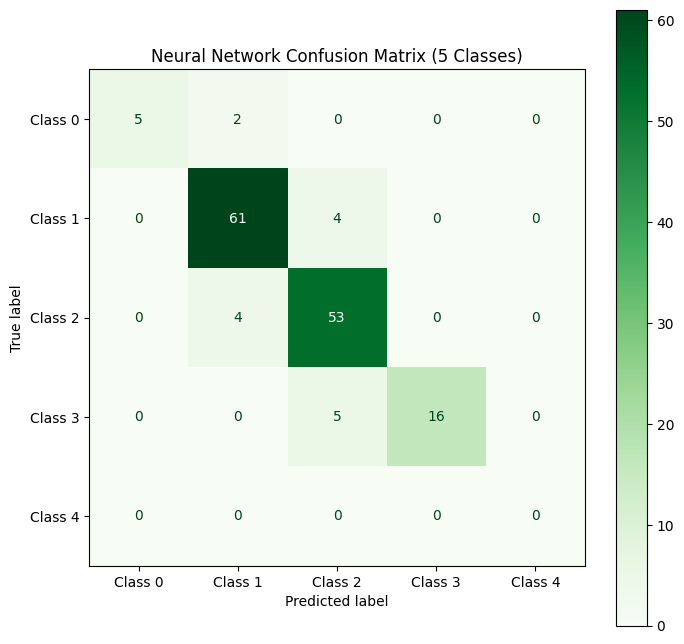

In [19]:
predicted_probabilities = model.predict(x_test_std)

y_pred = np.argmax(predicted_probabilities, axis=1)


all_labels = [0, 1, 2, 3, 4]
class_names = ['Class 0', 'Class 1', 'Class 2', 'Class 3', 'Class 4']

cm = confusion_matrix(y_test, y_pred, labels=all_labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(cmap=plt.cm.Greens, ax=ax)
plt.title('Neural Network Confusion Matrix (5 Classes)')
plt.show()


In [20]:
from sklearn.metrics import accuracy_score


In [21]:
predicted_probabilities = model.predict(x_test_std)

y_pred = np.argmax(predicted_probabilities, axis=1)



accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Test Accuracy: {accuracy * 100:.2f}%")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Overall Test Accuracy: 90.00%


## Model 1

In [22]:
import time
start = time.time()
model1 = keras.Sequential([
    layers.Dense(units=32, activation='relu', input_shape=(14,)),
    
    layers.Dense(units=16, activation='relu'),
    
    
    layers.Dense(units=5, activation='softmax')
])

model1.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
end = time.time()
execution_time = end - start
print(f"Training completed in: {execution_time:.4f} seconds")
model1.summary()



Training completed in: 0.0205 seconds


d:\Learning\Machine_learning\venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 32)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,093 (4.27 KB)

 Trainable params: 1,093 (4.27 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
start = time.time()
history1 = model1.fit(x_train_std, y_train, epochs=100, batch_size=10,validation_data=(x_cv_std,y_cv))
end = time.time()
print(end - start)

Epoch 1/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4218 - loss: 1.3728 - val_accuracy: 0.5359 - val_loss: 1.2464
Epoch 2/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5882 - loss: 1.0951 - val_accuracy: 0.5752 - val_loss: 1.0775
Epoch 3/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6528 - loss: 0.9261 - val_accuracy: 0.6405 - val_loss: 0.9470
Epoch 4/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7030 - loss: 0.7955 - val_accuracy: 0.6928 - val_loss: 0.8319
Epoch 5/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7676 - loss: 0.6837 - val_accuracy: 0.7386 - val_loss: 0.7305
Epoch 6/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8049 - loss: 0.5914 - val_accuracy: 0.7582 - val_loss: 0.6556
Epoch 7/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8594 - loss: 0.5137 - val_accuracy: 0.7778 - val_loss: 0.5885
Epoch 8/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8766 - loss: 0.4491 - val_accuracy: 0.7908 - v

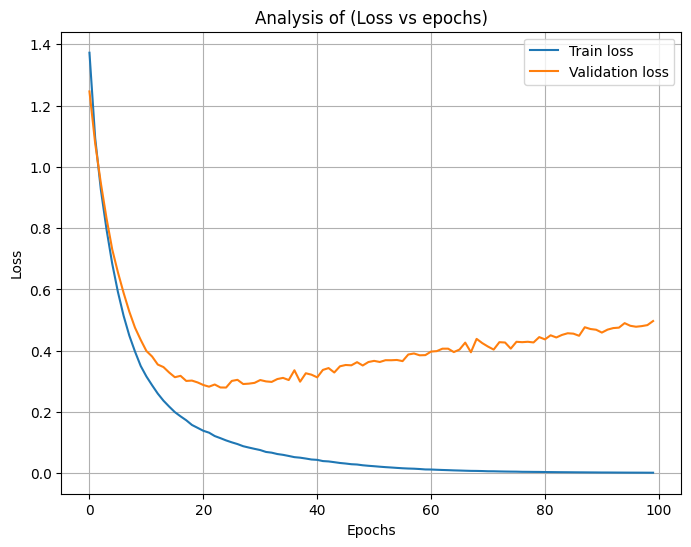

In [24]:
l = history1.history['loss']
t = history1.history['val_loss']
plt.figure(figsize=(8, 6))
plt.plot(l,label = "Train loss")
plt.plot(t,label = "Validation loss")

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Analysis of (Loss vs epochs)')
plt.legend()
plt.grid(True)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


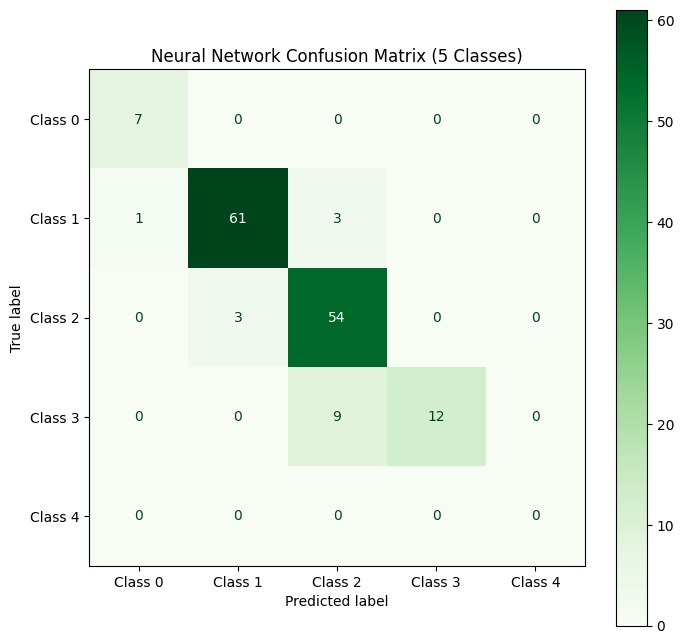

In [25]:
predicted_probabilities = model1.predict(x_test_std)

y_pred = np.argmax(predicted_probabilities, axis=1)


all_labels = [0, 1, 2, 3, 4]
class_names = ['Class 0', 'Class 1', 'Class 2', 'Class 3', 'Class 4']

cm = confusion_matrix(y_test, y_pred, labels=all_labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(cmap=plt.cm.Greens, ax=ax)
plt.title('Neural Network Confusion Matrix (5 Classes)')
plt.show()


In [26]:
predicted_probabilities = model1.predict(x_test_std)

y_pred = np.argmax(predicted_probabilities, axis=1)



accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Test Accuracy: {accuracy * 100:.2f}%")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Overall Test Accuracy: 89.33%


## Model 2


In [27]:
model2 = keras.Sequential([
    layers.Dense(units=32, activation='relu', input_shape=(14,)),
    
    layers.Dense(units=16, activation='relu'),
    
    
    layers.Dense(units=5, activation='softmax')
])

model2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model2.summary()



d:\Learning\Machine_learning\venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 32)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,093 (4.27 KB)

 Trainable params: 1,093 (4.27 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
history2 = model2.fit(x_train_std, y_train, epochs=100, batch_size=30,validation_data=(x_cv_std,y_cv))

Epoch 1/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.1793 - loss: 1.7120 - val_accuracy: 0.3399 - val_loss: 1.5526
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4075 - loss: 1.4191 - val_accuracy: 0.4706 - val_loss: 1.3540
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5481 - loss: 1.2326 - val_accuracy: 0.5033 - val_loss: 1.2224
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5968 - loss: 1.1031 - val_accuracy: 0.5163 - val_loss: 1.1361
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6370 - loss: 1.0080 - val_accuracy: 0.5621 - val_loss: 1.0652
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6657 - loss: 0.9340 - val_accuracy: 0.5817 - val_loss: 1.0101
Epoch 7/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7016 - loss: 0.8710 - val_accuracy: 0.6209 - val_loss: 0.9577
Epoch 8/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7360 - loss: 0.8131 - val_accuracy: 0.6340 - 

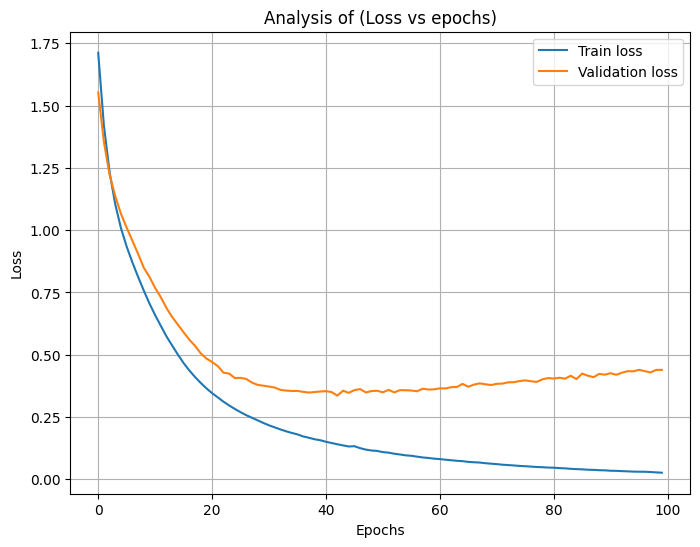

In [29]:
l = history2.history['loss']
t = history2.history['val_loss']
plt.figure(figsize=(8, 6))
plt.plot(l,label = "Train loss")
plt.plot(t,label = "Validation loss")

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Analysis of (Loss vs epochs)')
plt.legend()
plt.grid(True)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


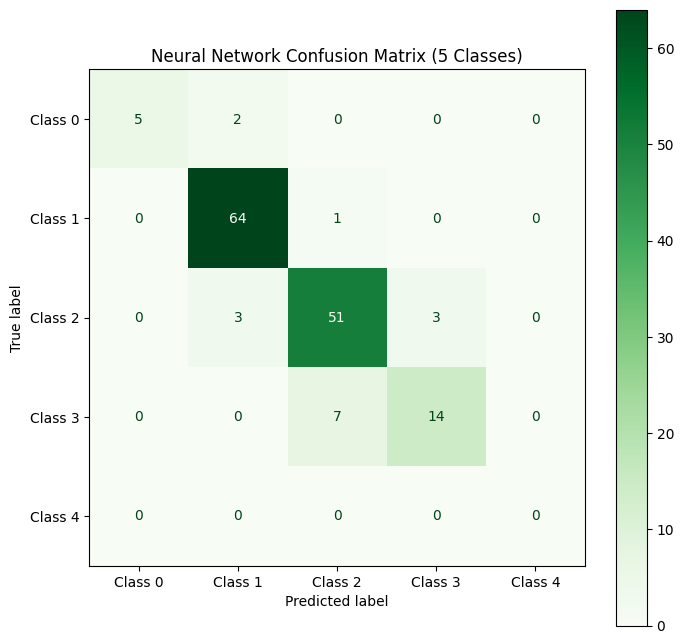

In [30]:
predicted_probabilities = model2.predict(x_test_std)

y_pred = np.argmax(predicted_probabilities, axis=1)


all_labels = [0, 1, 2, 3, 4]
class_names = ['Class 0', 'Class 1', 'Class 2', 'Class 3', 'Class 4']

cm = confusion_matrix(y_test, y_pred, labels=all_labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(cmap=plt.cm.Greens, ax=ax)
plt.title('Neural Network Confusion Matrix (5 Classes)')
plt.show()


In [31]:
predicted_probabilities = model2.predict(x_test_std)

y_pred = np.argmax(predicted_probabilities, axis=1)



accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Test Accuracy: {accuracy * 100:.2f}%")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Overall Test Accuracy: 89.33%


## Model 3

d:\Learning\Machine_learning\venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 16)             │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 5)              │            25 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 437 (1.71 KB)

 Trainable params: 437 (1.71 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.0732 - loss: 1.7265 - val_accuracy: 0.1242 - val_loss: 1.6784
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2080 - loss: 1.6012 - val_accuracy: 0.2353 - val_loss: 1.6034
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3501 - loss: 1.5328 - val_accuracy: 0.3203 - val_loss: 1.5595
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4118 - loss: 1.4812 - val_accuracy: 0.3791 - val_loss: 1.5247
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4519 - loss: 1.4330 - val_accuracy: 0.4052 - val_loss: 1.4930
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4763 - loss: 1.3846 - val_accuracy: 0.3987 - val_loss: 1.4659
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5050 - loss: 1.3358 - val_accuracy: 0.3922 - val_loss: 1.4409
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5050 - loss: 1.2940 - val_accuracy: 0.3725 - val_loss

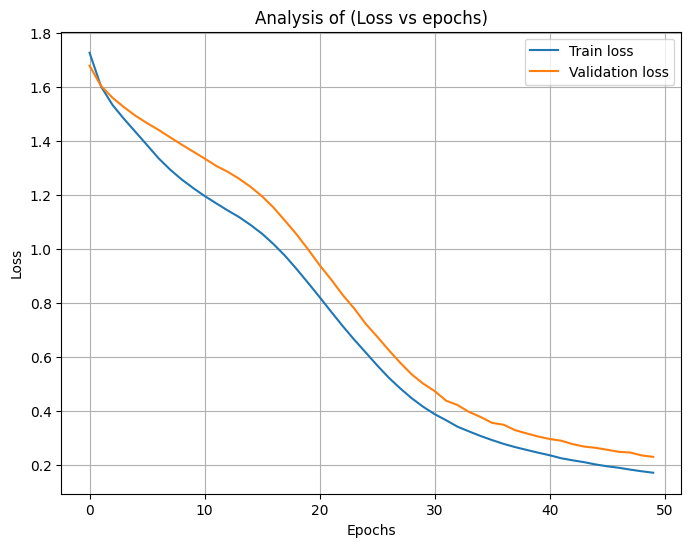

In [32]:
model3 = keras.Sequential([
    layers.Dense(units=16, activation='relu', input_shape=(14,)),
    
    layers.Dense(units=8, activation='relu'),

    layers.Dense(units=4, activation='relu'),
    
    layers.Dense(units=5, activation='softmax')
])

model3.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model3.summary()

history3 = model3.fit(x_train_std, y_train, epochs=50, batch_size=40,validation_data=(x_cv_std,y_cv))

l = history3.history['loss']
t = history3.history['val_loss']
plt.figure(figsize=(8, 6))
plt.plot(l,label = "Train loss")
plt.plot(t,label = "Validation loss")

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Analysis of (Loss vs epochs)')
plt.legend()
plt.grid(True)
plt.show()

